Authors: Noelle Anderson, Robert Poston, & Marisol Fermin Flores

# Welcome Data Explorers

You have already been building up your coding skills and this week will ask you to work a little more independently.

The goal is to use a rich environmental justice dataset, think creatively with your group, and build answers to your own questions.

The dataset used in the original lab comes from the California Office of Environmental Health and Hazard Assessment and includes pollution, health, demographic, and socioeconomic information by census tract.

Your goals with the CalEnviroScreen dataset are to:

1. Explore the data dictionary and decide which columns are useful for your questions.

2. Come up with at least 1 questions to address with your group.

3. Make predictions for those questions before you analyze the data.

4. Walk through the example code in Python.

5. Talk through a plan or pseudocode before writing your analysis.

6. Write Python code to execute your analyses and visualize your results.

7. Interpret the results and compare them to your hypotheses.

8. Share your findings with slack (optional).




# Exploring the Data

First, watch these 2 short videos to contextualize the dataset and its
uses. Note that the Cal OEHHA discusses "disadvantaged communities" in a
very passive voice, but important here to remember that systems and
structures of oppression very actively and passively *disadvantage* our
communities.

Video 1:
<https://www.youtube.com/watch?v=h-fhScBB7xM&ab_channel=OfficeofEnvironmentalHealthHazardAssessment%28OEHHA%29>
(5m)

Video 2:
<https://www.youtube.com/watch?v=J8NpXb2qfK8&ab_channel=OfficeofEnvironmentalHealthHazardAssessment%28OEHHA%29>
(5m)

QUESTION 1: Discuss the videos with your group. What did you learn or think from the videos?


In [ ]:
# Answer:

Optional: You may also want to explore the GIS-based map version of this
data:
<https://experience.arcgis.com/experience/11d2f52282a54ceebcac7428e6184203/page/CalEnviroScreen-4_0/>.
Check out the Indicator Maps on the top right tab as well.

Optional: And Cal OEHHA's uses for this data:
<https://oehha.ca.gov/calenviroscreen/how-use#>[:\~:text=DTSC%20uses%20CalEnviroScreen%20to%20identify,%2C%20complaints%2C%20and%20groundwater%20investigations.](https://oehha.ca.gov/calenviroscreen/how-use#:~:text=DTSC%20uses%20CalEnviroScreen%20to%20identify,%2C%20complaints%2C%20and%20groundwater%20investigations.)


# Download the data

Download the file from this page:

https://oehha.ca.gov/calenviroscreen/report/calenviroscreen-40

Scroll to the bottom of the webpage and click **CalEnviroScreen 4.0 Excel and Data Dictionary PDF** to download the workbook, then unzip the file if needed.

**Note:** The lab files are already available in the course drive.

Before working in Python, it is often helpful to explore the file in Excel or another spreadsheet program.

Open the workbook and look at the **data dictionary** first. A data dictionary explains what each column means, which is especially useful when column names are short or unclear.

Then look at the first sheet, which contains the main data. If you want to use the demographic information, explore the second sheet as well.

As you explore, ask yourself:

- What does each column measure?
- Which columns might help answer your question?
- Are there any values that look missing, strange, or unclear?

After your group has explored the data, collect possible questions and narrow them down to at least three ideas to investigate.

**QUESTION 2:** Describe at least one question you and your group would like to address.

In [ ]:
# Answer:

**QUESTION 3:** What do you and your group predict you will find for the question(s) you asked?

In [ ]:
# Answer:

**QUESTION 4:** Which variables in the dataset will be needed to answer your question(s)?


In [ ]:
# Answer:

**QUESTION 5:** Which column or columns would be most useful for joining the demographic data with the original dataset?

When we work with multiple files, we usually need a shared ID so we can match rows that belong together. Here, several columns are shared between `CES4.0FINAL_results` and the demographic profile dataset, so you may need more than one column to make the merge work correctly.

In [ ]:
# Answer:

# Example Analysis

In Python, the easiest way to inspect the workbook is with `pandas`. You can load the file, print the sheet names, and read the sheet you need.

If the second sheet has extra title rows at the top, use `skiprows` so the headers line up correctly.

You will need this data in your Google Drive, and you may need to change the file path so Python can find it.

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# change path if needed
workbook_path = '/content/drive/MyDrive/ColabNotebooks/scip/calenviroscreen40resultsdatadictionaryf2021/calenviroscreen40resultsdatadictionary_F_2021.xlsx'

# Inspect sheet names first

xls = pd.ExcelFile(workbook_path)
print(xls.sheet_names)

# Read the main sheet
main_df = pd.read_excel(workbook_path, sheet_name=0)

# Read the demographic sheet if needed

# Adjust skiprows if the header is not on the first row

demographic_df = pd.read_excel(workbook_path, sheet_name=1, header=1)
print(demographic_df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['CES4.0FINAL_results', 'Demographic Profile', 'Data Dictionary']
Index(['Census Tract', 'CES 4.0 Score', 'CES 4.0 Percentile',
       'CES 4.0 Percentile Range', 'California County', 'Total Population',
       'Children < 10 years (%)', 'Pop 10-64 years (%)',
       'Elderly > 64 years (%)', 'Hispanic (%)', 'White (%)',
       'African American (%)', 'Native American (%)', 'Asian American (%)',
       'Other/Multiple (%)'],
      dtype='object')


In [ ]:
#print(demographic_df)
#print(demographic_df.columns)
#print(main_df)

      Census Tract  Total Population California County    ZIP  \
0       6019001100              2780           Fresno   93706   
1       6077000700              4680       San Joaquin  95206   
2       6037204920              2751       Los Angeles  90023   
3       6019000700              3664           Fresno   93706   
4       6019000200              2689           Fresno   93706   
...            ...               ...               ...    ...   
8030    6107004000               582           Tulare   93257   
8031    6109985202              2509         Tuolumne   95327   
8032    6111001206               778          Ventura   93001   
8033    6111003012               675          Ventura   93036   
8034    6111980000               118          Ventura      61   

                     Approximate Location   Longitude   Latitude  \
0                                  Fresno -119.781696  36.709695   
1                                Stockton -121.287873  37.943173   
2              

**Question 7:** Add a code block to read in sheet 2 as a dataframe called `demographic_df`.

Check whether both the main data and the demographic data loaded correctly. Do the headers, column names, and row locations look right in Python? If needed, try the `skiprows` argument and read the sheet again.



First, set up the environment by loading the packages you will need.

- `pandas` helps with data tables
- `matplotlib` and `seaborn` help make plots
- `scipy` gives us statistical tests

These tools will help you explore, visualize, and compare the data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



Next, read in the main data and, if needed, merge it with the demographic sheet using the shared key column(s).

If your workbook already has clean headers, you can merge directly. If the headers are messy or shifted, fix the header rows first.

The goal is to create one clean table that contains the variables you need for your analysis.

In [ ]:
joined_df = main_df.merge(
    demographic_df,
    on="Census Tract",
    how="inner",
    suffixes=("", "_demo")
)

joined_df = joined_df.loc[:, ~joined_df.columns.str.endswith("_demo")]

# Visualization

A good plot helps tell the story of your data.

Choose a visualization that matches your question, and always label the axes clearly. The examples below show a few common approaches you can use in this lab.



**Example 1:** Summarize the mean pesticide level per county and show the result as a bar plot.

A bar plot is useful when you want to compare values across categories.

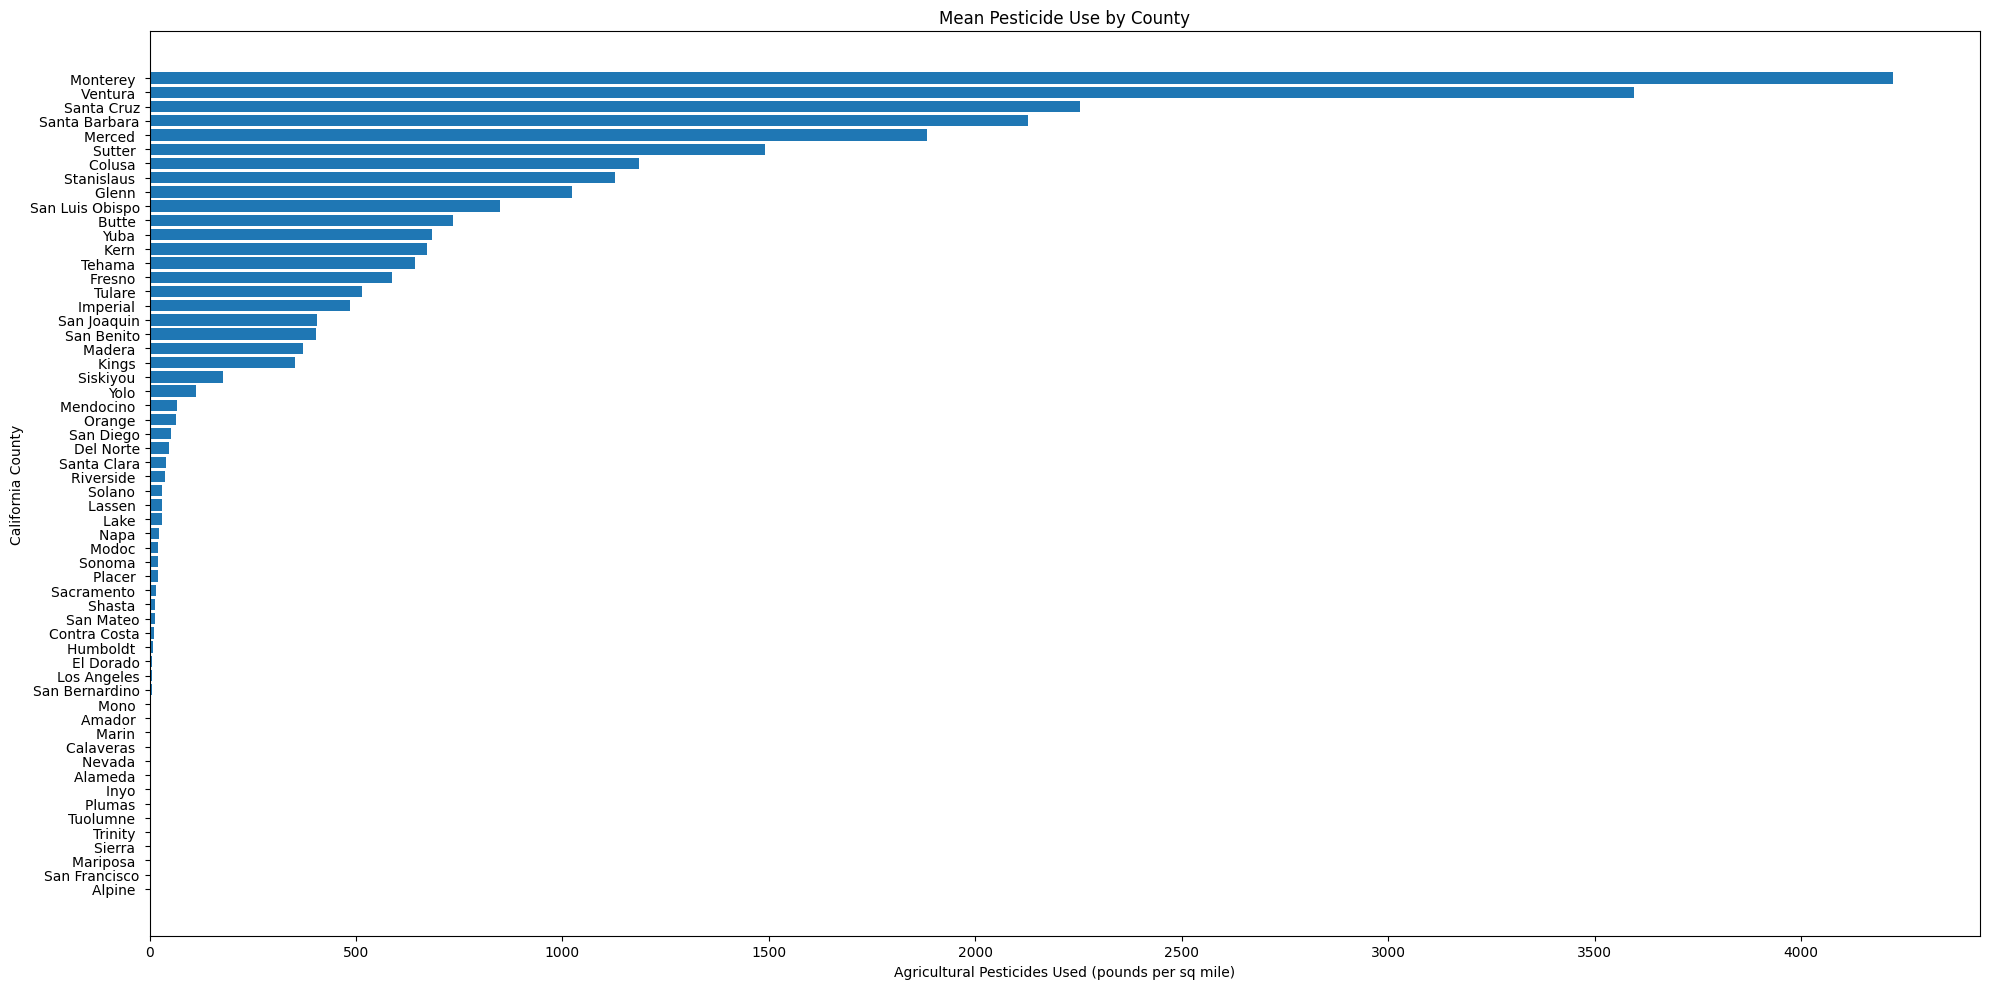

In [ ]:
# --- Step 1: Summarize (like group_by + summarize) ---
pesticides_by_county = (
    joined_df
    .groupby('California County', as_index=False)
    .agg(mean_Pesticides=('Pesticides', 'mean'))
)

# --- Step 2: Reorder (like reorder() in ggplot) ---
pesticides_by_county = pesticides_by_county.sort_values('mean_Pesticides')

# --- Step 3: Plot (like ggplot + geom_bar + coord_flip) ---
plt.figure(figsize=(20, 10))

plt.barh(   # horizontal bar = coord_flip()
    pesticides_by_county['California County'],
    pesticides_by_county['mean_Pesticides']
)

plt.xlabel("Agricultural Pesticides Used (pounds per sq mile)")
plt.ylabel("California County")
plt.title("Mean Pesticide Use by County")

plt.tight_layout()
plt.show()

**Example 2:** Use a scatter plot to look at the relationship between total population and traffic.

Because some values may be very large, the y-axis is shown on a log scale so the pattern is easier to see.

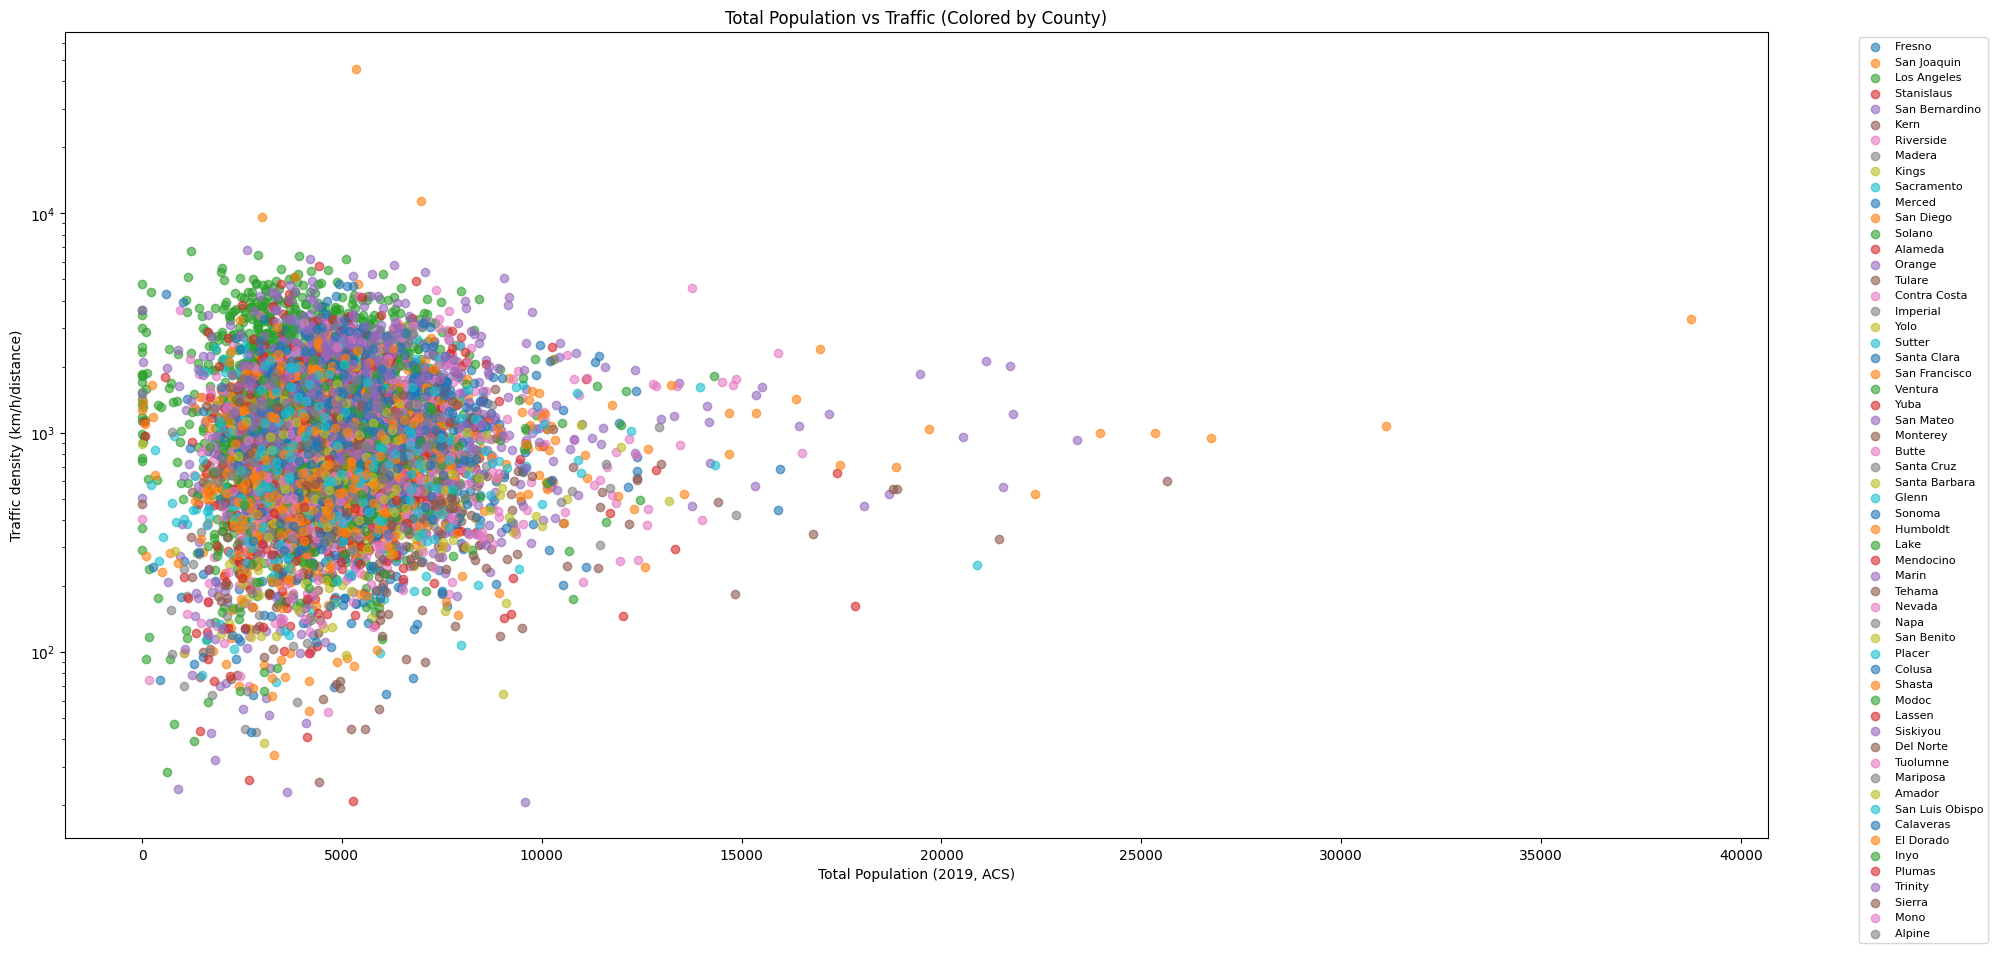

In [ ]:
plt.figure(figsize=(20, 10))

for county in joined_df['California County'].unique():
    subset = joined_df[joined_df['California County'] == county]

    plt.scatter(
        subset['Total Population'],
        subset['Traffic'],
        alpha=0.6,
        label=county
    )

plt.xlabel('Total Population (2019, ACS)')
plt.ylabel('Traffic density (km/h/distance)')
plt.yscale('log')
plt.title('Total Population vs Traffic (Colored by County)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

If things look weird in your plots, check that the columns are numeric and that missing values are handled properly.

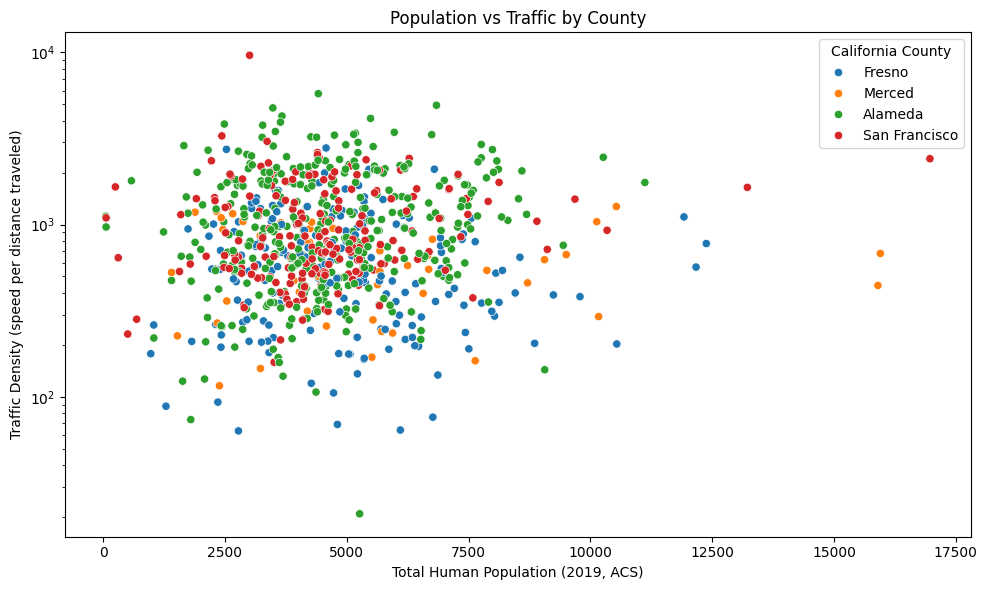

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Create subset list ---
county_subset = ["Alameda", "San Francisco", "Merced", "Fresno"]

# --- Step 2: Filter data (like %in%) ---
subset_df = joined_df[joined_df["California County"].isin(county_subset)]

# --- Step 3: Plot (like ggplot) ---
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=subset_df,
    x="Total Population",
    y="Traffic",
    hue="California County"   # color by county
)

plt.xlabel("Total Human Population (2019, ACS)")
plt.ylabel("Traffic Density (speed per distance traveled)")
plt.yscale("log")   # same as scale_y_log10()

plt.title("Population vs Traffic by County")

plt.tight_layout()
plt.show()

/tmp/ipykernel_290/2804122243.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


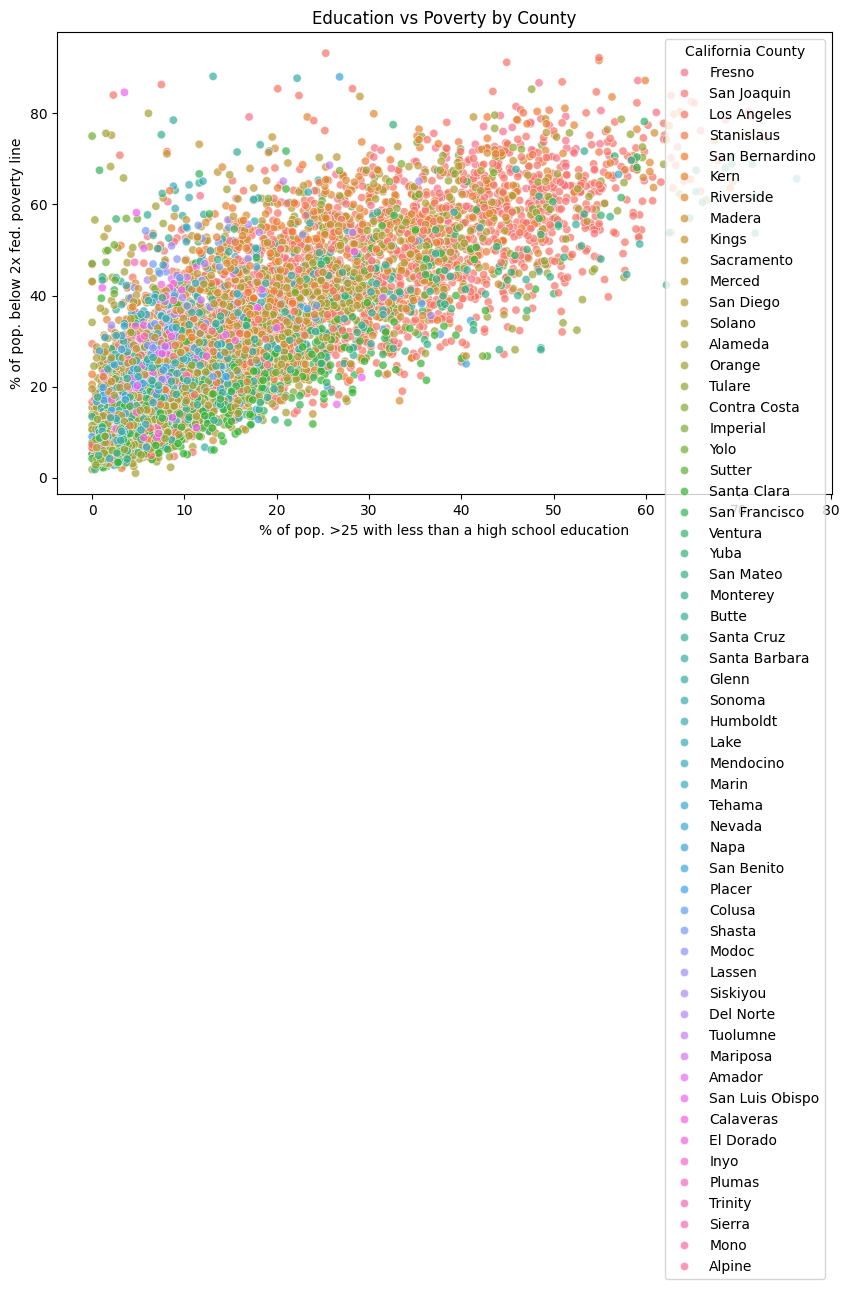

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert Education to numeric (like as.numeric in R)
joined_df['Education'] = pd.to_numeric(joined_df['Education'], errors='coerce')

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=joined_df,
    x='Education',
    y='Poverty',
    hue='California County',   #color by county
    alpha=0.7
)

plt.xlabel('% of pop. >25 with less than a high school education')
plt.ylabel('% of pop. below 2x fed. poverty line')
plt.title('Education vs Poverty by County')

plt.tight_layout()
plt.show()

In [ ]:
joined_df['eduPop'] = 100 - pd.to_numeric(joined_df['Education'], errors='coerce')

/tmp/ipykernel_290/3588807500.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


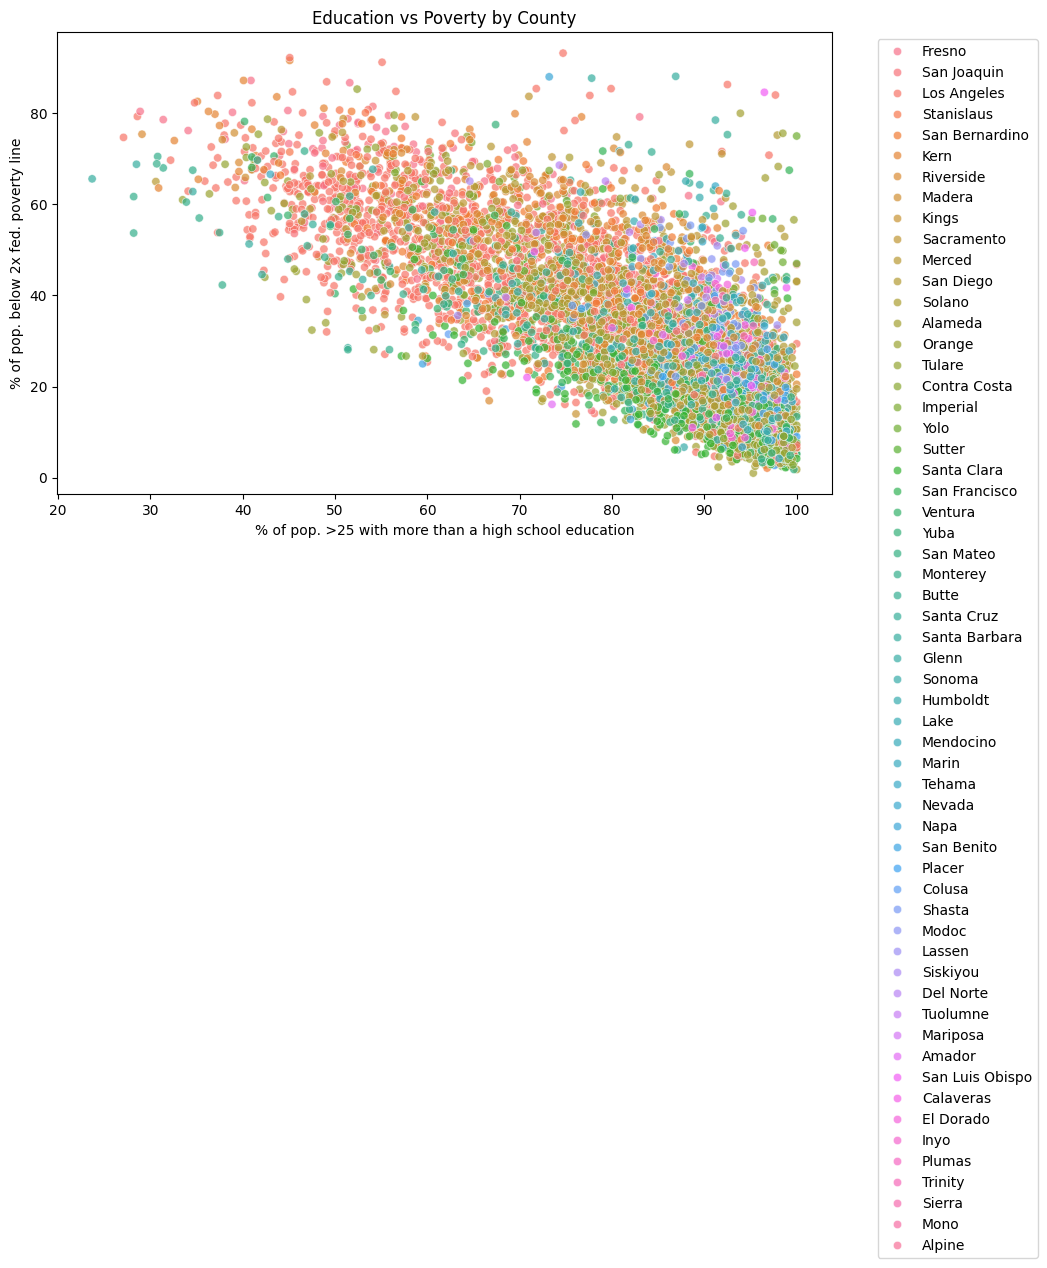

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Make sure eduPop exists and is numeric
joined_df['eduPop'] = pd.to_numeric(joined_df['eduPop'], errors='coerce')
joined_df['Poverty'] = pd.to_numeric(joined_df['Poverty'], errors='coerce')

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=joined_df,
    x='eduPop',
    y='Poverty',
    hue='California County',
    alpha=0.7
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('% of pop. >25 with more than a high school education')
plt.ylabel('% of pop. below 2x fed. poverty line')
plt.title('Education vs Poverty by County')

plt.tight_layout()
plt.show()

# Statistics Examples

Sometimes we want to know whether two variables move together. For example, do census tracts with higher poverty rates also tend to have lower educational attainment?

To explore that relationship, we can use **Spearman's rank correlation** with `scipy.stats.spearmanr`.

Spearman's correlation is useful when:

- the relationship may not be perfectly linear
- the data are not normally distributed
- we want to check whether values tend to increase or decrease together

The result gives us two important pieces of information:

- **rho (ρ):** the strength and direction of the relationship
- **p-value:** whether the relationship is likely to be real or just due to chance

A negative rho means that as one variable goes up, the other tends to go down.

In [ ]:
edu_pop = joined_df['Education']
poverty = pd.to_numeric(joined_df['Poverty'], errors='coerce')

rho, p_value = stats.spearmanr(edu_pop, poverty, nan_policy='omit')

print(rho, p_value)

0.7941660508468793 0.0


Next, we want to compare two groups and ask whether drinking water contamination looks different in Merced and Marin.

Here we are comparing the values from one county to the values from another county. That means we need a test that tells us whether the two groups come from the same overall distribution.


# Testing assumptions and hypotheses about group differences.

Before choosing a test, we should look at the data and think about the assumptions behind it.

Some tests assume the data are roughly normal and have similar spread across groups. If those assumptions do not look reasonable, a non-parametric test may be a better choice.

Start by checking the shape of your data.

A histogram is a quick way to see whether the values look roughly symmetric or strongly skewed. This helps us decide whether a parametric test or a non-parametric test is more appropriate.

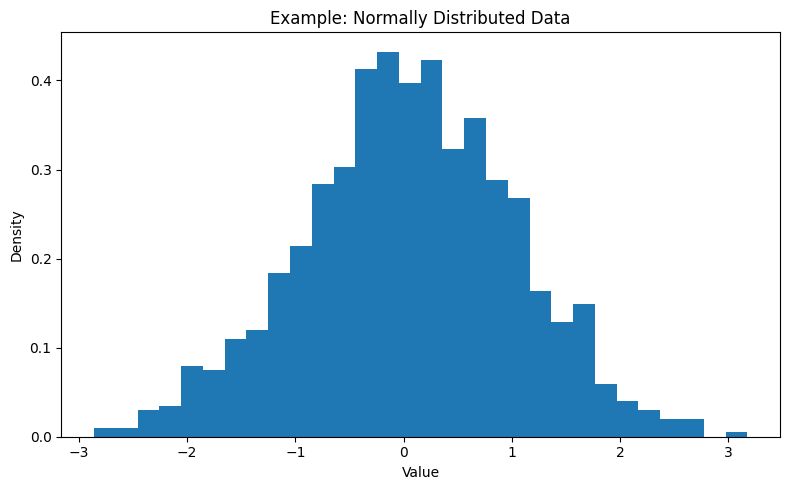

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Example normal distribution (normalized) ---
plt.figure(figsize=(8, 5))

data = np.random.normal(loc=0, scale=1, size=1000)

plt.hist(data, bins=30, density=True)

plt.title('Example: Normally Distributed Data')
plt.xlabel('Value')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

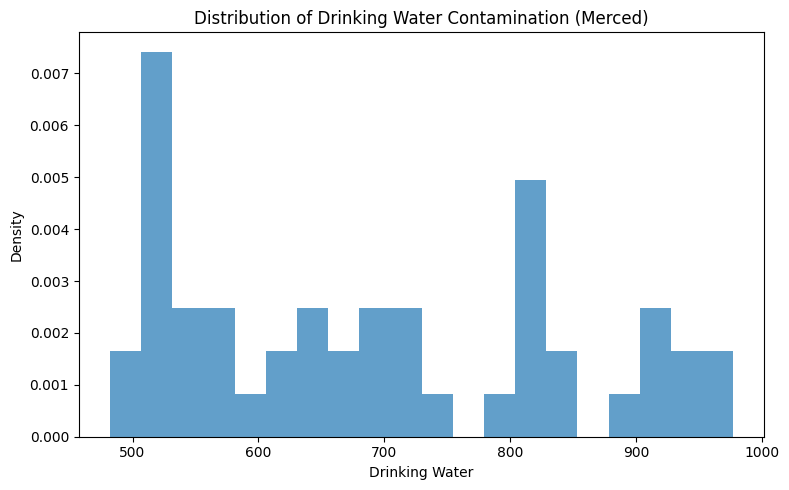

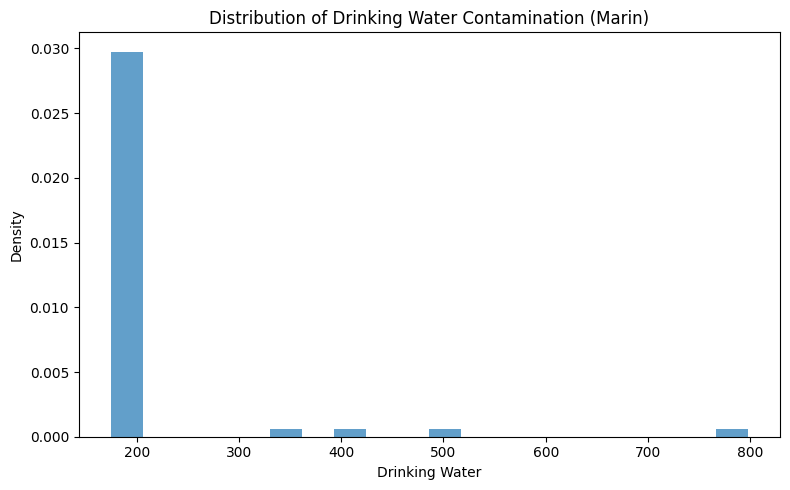

In [ ]:
# --- Clean county names ---
joined_df['California County'] = joined_df['California County'].str.strip()

# --- Filter counties ---
merced = joined_df[joined_df['California County'].str.contains('Merced', na=False)]
marin = joined_df[joined_df['California County'].str.contains('Marin', na=False)]

# --- Merced distribution ---
plt.figure(figsize=(8, 5))

plt.hist(
    merced['Drinking Water'].dropna(),
    bins=20,
    density=True,   # shows distribution shape
    alpha=0.7
)

plt.title('Distribution of Drinking Water Contamination (Merced)')
plt.xlabel('Drinking Water')
plt.ylabel('Density')

plt.tight_layout()
plt.show()


# --- Marin distribution ---
plt.figure(figsize=(8, 5))

plt.hist(
    marin['Drinking Water'].dropna(),
    bins=20,
    density=True,
    alpha=0.7
)

plt.title('Distribution of Drinking Water Contamination (Marin)')
plt.xlabel('Drinking Water')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

These distributions look quite different from our simulation. They do not look very normal, and they do not have similar spread. The Marin data also looks strongly skewed.

Because of that, we should test normality more formally using the Shapiro-Wilk test.

**Shapiro-Wilk test for normality**

- **Null hypothesis (H₀):** the data are normally distributed
- **Alternative hypothesis (H₁):** the data are not normally distributed

How to interpret the p-value:

- **p > 0.05**: the data are reasonably consistent with normality
- **p < 0.05**: there is evidence that the data are not normally distributed

We usually look at both the histogram and the test result together.

In [ ]:
from scipy import stats

# Drop missing values
merced_dw = merced['Drinking Water'].dropna()
marin_dw = marin['Drinking Water'].dropna()

# Shapiro-Wilk test
shapiro_merced = stats.shapiro(merced_dw)
shapiro_marin = stats.shapiro(marin_dw)

print("Merced Shapiro:", shapiro_merced)
print("Marin Shapiro:", shapiro_marin)

Merced Shapiro: ShapiroResult(statistic=np.float64(0.9150563720646456), pvalue=np.float64(0.0017708669818536356))
Marin Shapiro: ShapiroResult(statistic=np.float64(0.33094978662621066), pvalue=np.float64(2.0447307665860138e-14))


# Non-parametric options


If the data are strongly non-normal or skewed, a non-parametric test is often a better choice.

Non-parametric tests do not require the data to follow a normal distribution.

#Levene's test

Levene's test checks whether the two groups have similar variance, or spread.

- **Null hypothesis (H₀):** the variances are equal
- **Alternative hypothesis (H₁):** the variances are different

If the p-value is small, the variances are not equal, and Welch's t-test is usually safer than the standard t-test.

In [ ]:
levene_test = stats.levene(merced_dw, marin_dw)

print("Levene test:", levene_test)

Levene test: LeveneResult(statistic=np.float64(35.18560892407387), pvalue=np.float64(4.135675822401306e-08))


The Python version of the Wilcoxon rank-sum test is `scipy.stats.mannwhitneyu`.

This test is often used when the data are not normal or when a rank-based comparison is more appropriate.

In [ ]:
t_test = stats.ttest_ind(
    merced_dw,
    marin_dw,
    equal_var=False   # Welch's t-test
)

print("Welch t-test:", t_test)

Welch t-test: TtestResult(statistic=np.float64(18.907703330085933), pvalue=np.float64(2.7635574843072433e-31), df=np.float64(80.17913878643206))


**Wilcoxon / Mann-Whitney test**

This test compares two groups by looking at the ranks of the values rather than assuming the data are normally distributed.

In simple terms, it asks whether values from one group tend to be larger or smaller than values from the other group.

In [ ]:
mw_test = stats.mannwhitneyu(
    merced_dw,
    marin_dw,
    alternative='two-sided'
)

print("Mann-Whitney U test:", mw_test)

Mann-Whitney U test: MannwhitneyuResult(statistic=np.float64(2661.0), pvalue=np.float64(2.0635394924308683e-18))


QUESTION 8: If the null hypothesis in our Wilcoxon test is equal medians between groups, what does the resulting low p-value here tell us about how Merced and Marin compare for drinking water contamination levels?

In [ ]:
#Answer: